# DQN baseline on Four Rooms

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time

# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.fourrooms_discrete import FourRoomsGridWorld, FourRoomsGoalWrapper, make_env_fourrooms_discrete
from utils import TrajectoryReplayBufferDiscrete, evaluate_policy
from visualisations import plot_policy_rollouts, plot_q_diagnostics
from networks import DQN_QNetwork
from exploration.multi_agent_exploration_parallel import NumpyMultiAgentExplorer, make_discrete_transition_model

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


In [2]:
def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=500):
    base = FourRoomsGridWorld(room_size=5, max_episode_steps=max_horizon)
    env = FourRoomsGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
    )
    return env

BUFFER_CAPACITY=100000
GOAL=(9, 9)
LR= float(1e-3)

env = make_env(goal=GOAL)


## Multi-Agent explorer setup

In [3]:
ACTION_EFFECTS = {
    0: (0.0, 1.0),    # Up
    1: (0.0, -1.0),   # Down
    2: (-1.0, 0.0),   # Left
    3: (1.0, 0.0),    # Right
}

transition_model = make_discrete_transition_model(ACTION_EFFECTS)

N_AGENTS = 10

explorer = NumpyMultiAgentExplorer(
    n_agents=N_AGENTS,
    env_fn=lambda: make_env(goal=GOAL),
    candidate_actions=[0, 1, 2, 3],
    state_low=[0.0, 0.0],
    state_high=[9.0, 9.0],
    goal=[float(GOAL[0]), float(GOAL[1])],
    transition_model=transition_model,
    epsilon=1.0,
    novelty_scale=0.0,
    state_bins=[10, 10],
    rng_seed=0,
)

Discrete(4)
[[4.33194322 1.2804185 ]
 [6.9565469  1.8254877 ]
 [5.9459722  5.08247056]
 [1.83687617 8.09748894]
 [5.32148002 0.2697407 ]
 [1.14280804 4.20356197]
 [2.71487487 6.6453098 ]
 [8.94156518 5.9538466 ]
 [7.68926249 2.81185495]
 [0.57326552 8.9827518 ]]
[DQN] step=   1000 | eval_return=0.000 | eval_len=500.0
[DQN] step=   2000 | eval_return=0.000 | eval_len=500.0
[DQN] step=   3000 | eval_return=0.000 | eval_len=500.0
[DQN] step=   4000 | eval_return=0.000 | eval_len=500.0
[DQN] step=   5000 | eval_return=0.000 | eval_len=500.0
[DQN] step=   6000 | eval_return=0.000 | eval_len=500.0
[DQN] step=   7000 | eval_return=0.000 | eval_len=500.0
[DQN] step=   8000 | eval_return=0.000 | eval_len=500.0
[DQN] step=   9000 | eval_return=0.000 | eval_len=500.0
[DQN] step=  10000 | eval_return=0.000 | eval_len=500.0
[DQN] step=  11000 | eval_return=0.000 | eval_len=500.0
[DQN] step=  12000 | eval_return=0.125 | eval_len=437.8
[DQN] step=  13000 | eval_return=0.000 | eval_len=500.0
[DQN] ste

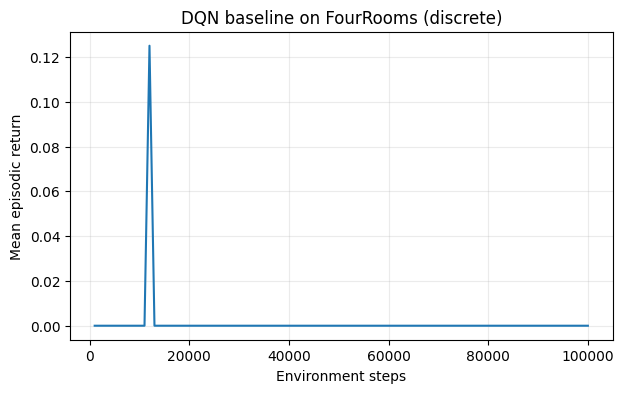

In [ ]:

obs_dim = env.observation_space.shape[0]
num_actions = env.action_space.n
print(env.action_space)


q_net = DQN_QNetwork(obs_dim, num_actions).to(DEVICE)
q_target = DQN_QNetwork(obs_dim, num_actions).to(DEVICE)
q_target.load_state_dict(q_net.state_dict())
for p in q_target.parameters():
    p.requires_grad_(False)



def multi_agent_dqn_train(
    q_network=q_net,
    q_target_network=q_target,
    env=env,
    buffer_capacity=BUFFER_CAPACITY,
    lr=LR,
    obs_dim=obs_dim,
    device=DEVICE,
    total_steps=100000,
    warmup_steps=5000,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=50000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    train_freq=4,
    goal=GOAL,
    params=None,
    eval_every=1000,
    multi_agent_explorer=explorer,
):
    if params is None:
        params = q_network.parameters()

    opt = optim.Adam(params, lr=lr)
    buffer = TrajectoryReplayBufferDiscrete(
        buffer_capacity, obs_dim, 1, device=device
    )

    # Reset explorer (e.g., reinitialise all agent envs, LHS seeds, etc.)
    initial_states = multi_agent_explorer.reset()
    print(initial_states)

    global_step = 0
    eval_returns = []

    wall_clock_start = time.perf_counter()

    while global_step < total_steps:

        frac = min(1.0, global_step / eps_decay_steps)
        multi_agent_explorer.epsilon = eps_start + frac * (eps_end - eps_start)
    
        stats = multi_agent_explorer.collect_steps(
            replay_buffer=buffer,
            num_steps=1,              # one synchronized step for each agent
            flush_partial_episodes=False,
            q_network=q_network,
            device=device
        )

        global_step += stats["num_transitions"]
        
        # Training update (standard DQN)
        if len(buffer) >= warmup_steps and global_step % train_freq == 0:
            batch = buffer.sample(batch_size)

            obs_t = batch.obs
            act_t = batch.actions.long()  # gather indices
            rew_t = batch.rewards
            next_obs_t = batch.next_obs
            term_t = batch.terminated

            with torch.no_grad():
                next_q = q_target_network(next_obs_t).max(dim=-1, keepdim=True).values
                target = rew_t + gamma * (1.0 - term_t) * next_q

            current_q = q_network(obs_t).gather(1, act_t.unsqueeze(1))
            loss = F.mse_loss(current_q, target)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(q_network.parameters(), 10.0)
            opt.step()

            # Soft update target network
            for p, p_tgt in zip(q_network.parameters(), q_target_network.parameters()):
                p_tgt.data.mul_(1.0 - tau).add_(tau * p.data)

        # Periodic evaluation
        if global_step % eval_every == 0:
            eval_env = make_env(goal)
            mean_ret, mean_len = evaluate_policy(
                eval_env,
                lambda o: int(
                    q_network(
                        torch.tensor(
                            o, dtype=torch.float32, device=DEVICE
                        ).unsqueeze(0)
                    ).argmax(dim=-1).item()
                ),
                episodes=8,
            )
            eval_returns.append((global_step, mean_ret))
            print(
                f"[DQN] step={global_step:7d} | "
                f"eval_return={mean_ret:.3f} | eval_len={mean_len:.1f}"
            )
            eval_env.close()

    env.close()

    wall_clock_end = time.perf_counter()
    total_elapsed = wall_clock_end - wall_clock_start
    print(f"Total training wall-clock time: {total_elapsed:.1f} s")

    return q_network, eval_returns


# Run training
dqn_q_first, dqn_eval_first = multi_agent_dqn_train()

if dqn_eval_first:
    xs, ys = zip(*dqn_eval_first)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel("Environment steps")
    plt.ylabel("Mean episodic return")
    plt.title("DQN baseline on FourRooms (discrete)")
    plt.grid(alpha=0.25)
    plt.show()


## Visualisations

Episode 1: 500 steps | return: 0.00 | reached goal: False
Episode 2: 500 steps | return: 0.00 | reached goal: False
Episode 3: 500 steps | return: 0.00 | reached goal: False
Episode 4: 500 steps | return: 0.00 | reached goal: False
Episode 5: 500 steps | return: 0.00 | reached goal: False
Episode 6: 500 steps | return: 0.00 | reached goal: False
Episode 7: 500 steps | return: 0.00 | reached goal: False
Episode 8: 500 steps | return: 0.00 | reached goal: False

Success rate: 0.00% over 8 episodes
Average return: 0.00 ± 0.00


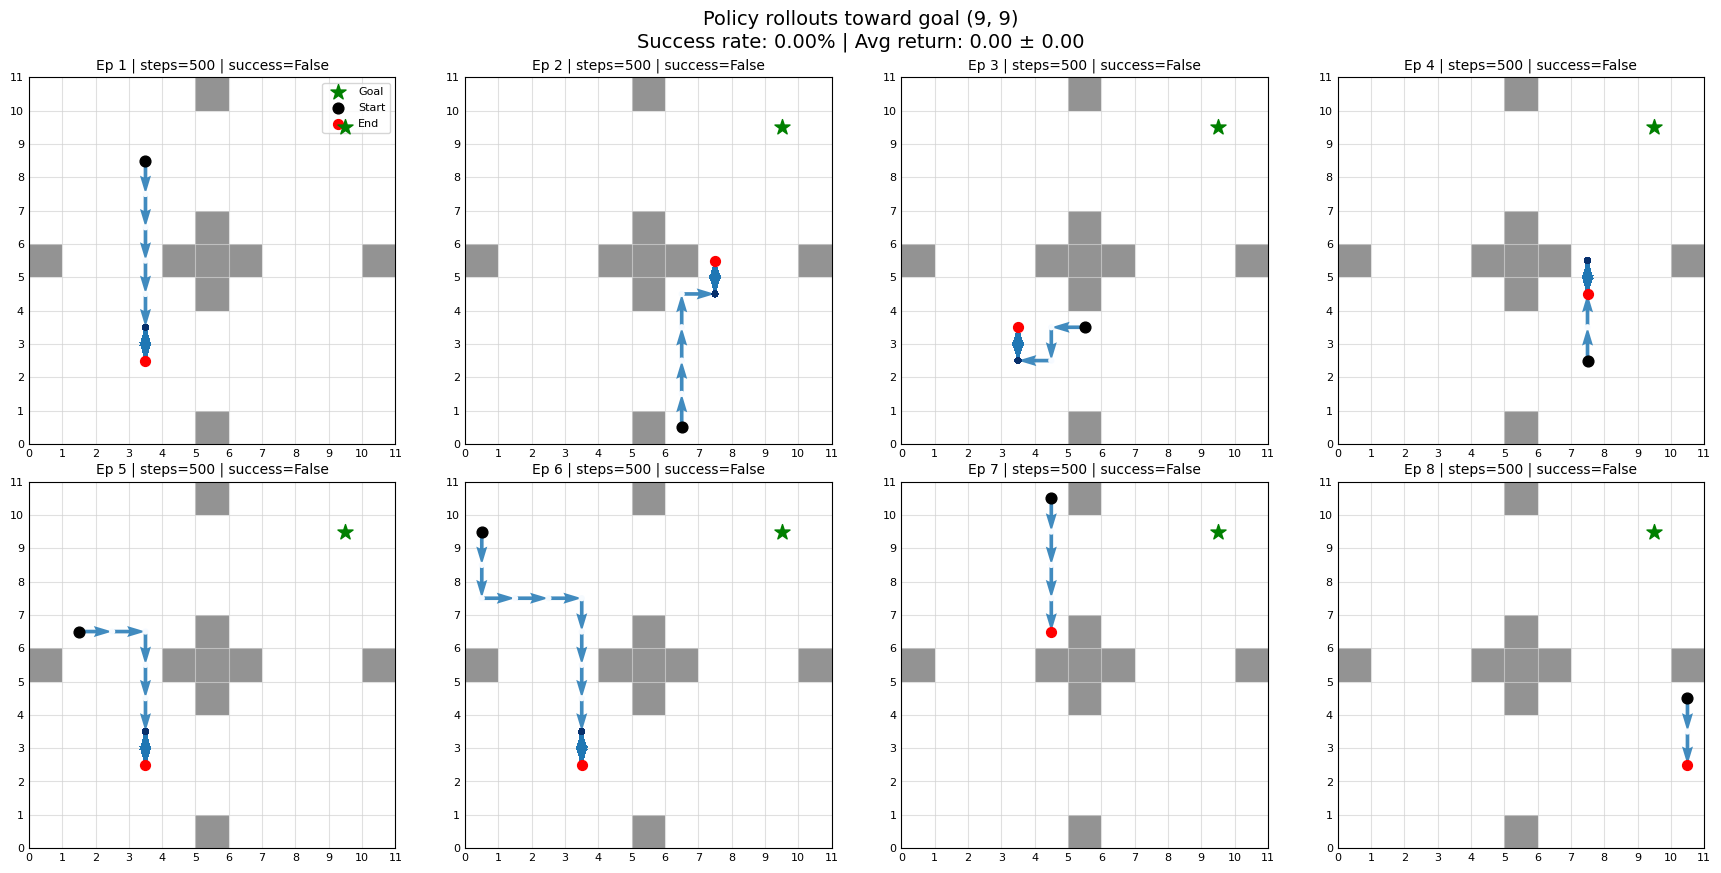

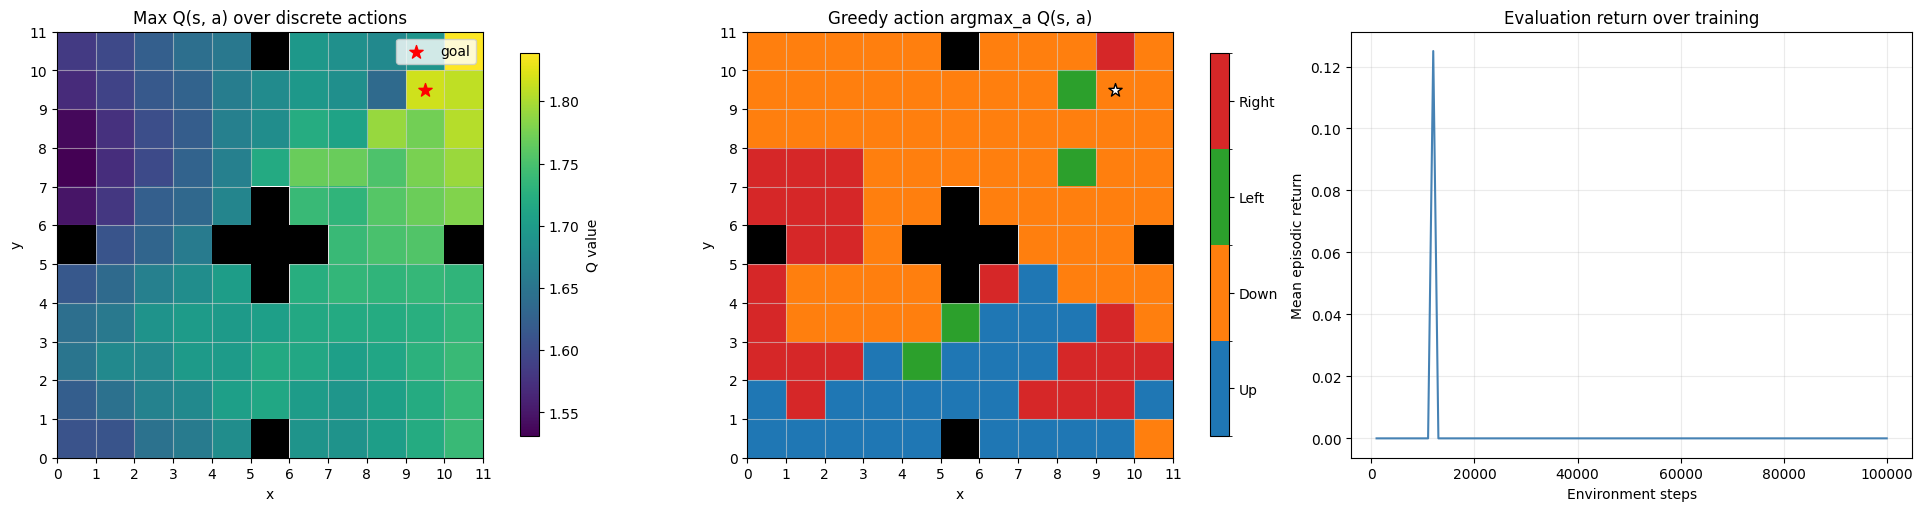

DQN_QNetwork(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
)

In [5]:

dqn_q_first.eval()
eval_env_first = make_env(goal=(9, 9))


def dqn_policy_fn(obs,q_network):
    obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        action = int(q_network(obs_t).argmax(dim=-1).item())
    return action


def dqn_value_fn(obs_batch, q_network):
    obs_t = torch.tensor(obs_batch, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        q_vals = q_network(obs_t).cpu().numpy()
    return q_vals


plot_policy_rollouts(
    env=eval_env_first,
    policy_fn=lambda obs: dqn_policy_fn(obs, q_network=dqn_q_first),
    goal_pos=(9, 9),
    eval_episodes=8,
    n_cols=4,
    is_discrete=True,
    step_point_size=12,
    start_size=60,
    end_size=50,
    goal_size=130,
    arrow_width=0.01,
)

eval_env_first.close()

eval_env_first = make_env(goal=(9, 9))

plot_q_diagnostics(
    env=eval_env_first,
    value_fn=lambda obs_batch: dqn_value_fn(obs_batch, q_network=dqn_q_first),
    actor_fn=None,
    is_discrete=True,
    num_actions=4,
    action_names=['Up', 'Down', 'Left', 'Right'],
    goal_pos=(9, 9),
    eval_returns=dqn_eval_first,
)

eval_env_first.close()

dqn_q_first.train()


## Now to check how much samples needed to reach a new goal